In [6]:
import yfinance as yf
df = yf.download('RELIANCE.NS', start='2023-01-01', end='2025-01-01')
print(df.head())
df.to_csv('reliance_stock.csv')


[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open      Volume
Ticker      RELIANCE.NS  RELIANCE.NS  RELIANCE.NS  RELIANCE.NS RELIANCE.NS
Date                                                                      
2023-01-02  1175.889648  1177.304802  1163.244669  1164.066352     5316175
2023-01-03  1167.284668  1174.565828  1163.062148  1170.936659     7658932
2023-01-04  1149.709595  1169.110728  1147.632506  1167.261851     9264891
2023-01-05  1147.655151  1157.857903  1143.067373  1151.969076    13637099
2023-01-06  1158.086304  1163.130627  1149.595501  1153.407240     6349597


In [8]:
import pandas as pd
print (df.shape)

(491, 5)


In [12]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# Data loading
df = yf.download('RELIANCE.NS', start='2023-01-01', end='2025-01-01')
df.reset_index(inplace=True)

print("Shape:", df.shape)
print(df.head())

[*********************100%***********************]  1 of 1 completed

Shape: (491, 6)
Price        Date        Close         High          Low         Open  \
Ticker             RELIANCE.NS  RELIANCE.NS  RELIANCE.NS  RELIANCE.NS   
0      2023-01-02  1175.889648  1177.304802  1163.244669  1164.066352   
1      2023-01-03  1167.284668  1174.565828  1163.062148  1170.936659   
2      2023-01-04  1149.709595  1169.110728  1147.632506  1167.261851   
3      2023-01-05  1147.655151  1157.857903  1143.067373  1151.969076   
4      2023-01-06  1158.086304  1163.130627  1149.595501  1153.407240   

Price       Volume  
Ticker RELIANCE.NS  
0          5316175  
1          7658932  
2          9264891  
3         13637099  
4          6349597  


In [13]:
# Basic info
print(df.info())
print("\nNull values:\n", df.isnull().sum())
print("\nBasic Stats:\n", df.describe())

# Date format fix
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')

<class 'pandas.DataFrame'>
RangeIndex: 491 entries, 0 to 490
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype        
---  ------                 --------------  -----        
 0   (Date, )               491 non-null    datetime64[s]
 1   (Close, RELIANCE.NS)   491 non-null    float64      
 2   (High, RELIANCE.NS)    491 non-null    float64      
 3   (Low, RELIANCE.NS)     491 non-null    float64      
 4   (Open, RELIANCE.NS)    491 non-null    float64      
 5   (Volume, RELIANCE.NS)  491 non-null    int64        
dtypes: datetime64[s](1), float64(4), int64(1)
memory usage: 23.1 KB
None

Null values:
 Price   Ticker     
Date                   0
Close   RELIANCE.NS    0
High    RELIANCE.NS    0
Low     RELIANCE.NS    0
Open    RELIANCE.NS    0
Volume  RELIANCE.NS    0
dtype: int64

Basic Stats:
 Price                  Date        Close         High          Low  \
Ticker                       RELIANCE.NS  RELIANCE.NS  RELIANCE.NS   
count           

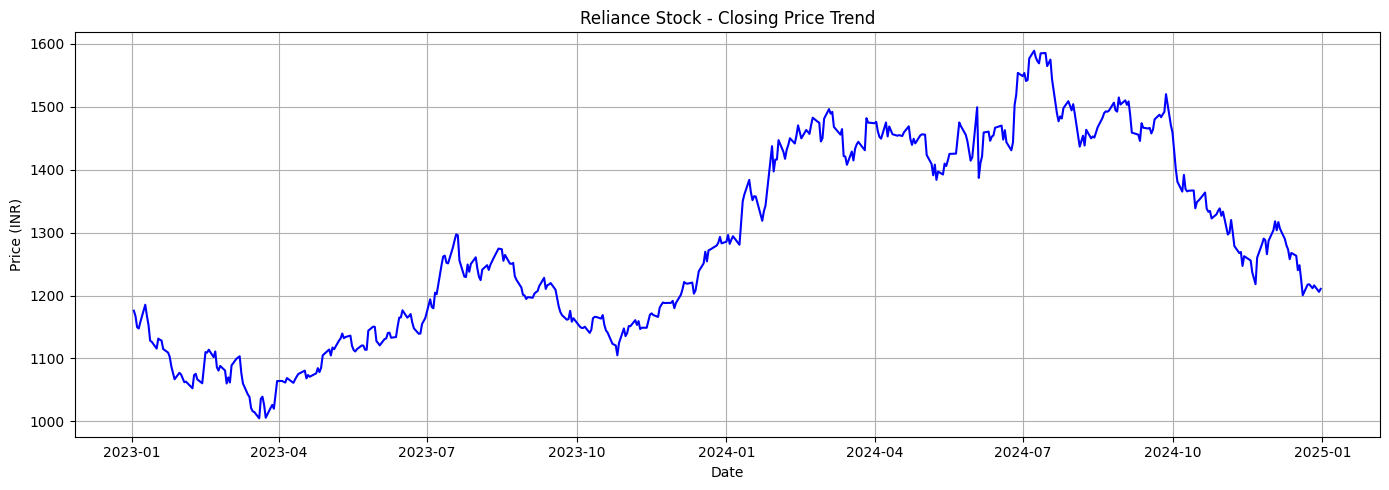

In [15]:
#Visualization
plt.figure(figsize=(14,5))
plt.plot(df['Date'], df['Close'], color='blue', linewidth=1.5)
plt.title('Reliance Stock - Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.grid(True)
plt.tight_layout()
plt.show()

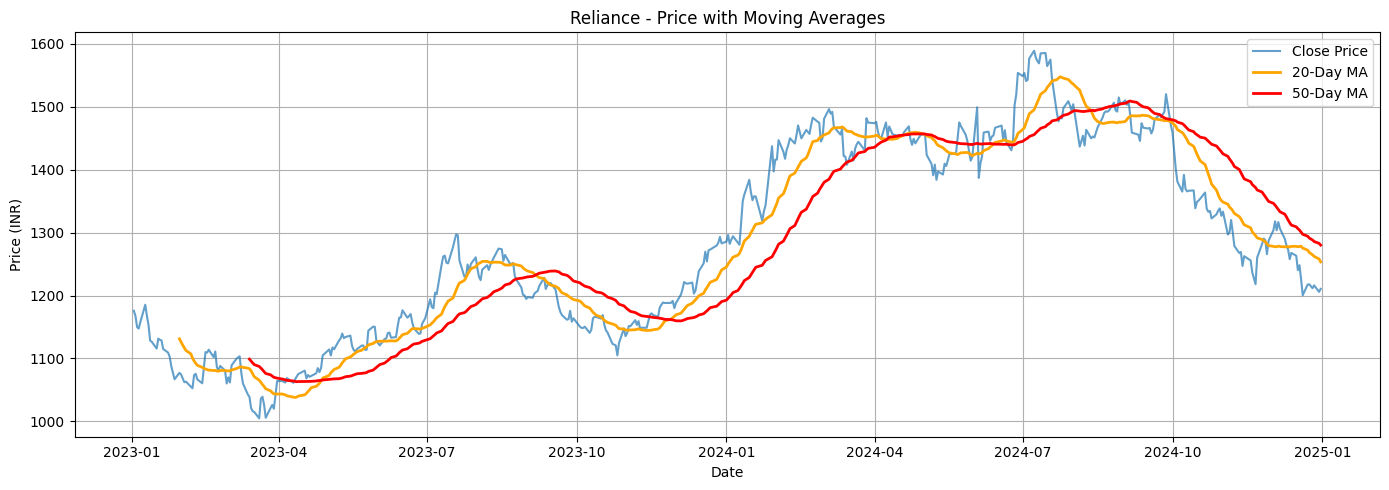

In [20]:
 #Moving Averages
df['MA_20'] = df['Close'].rolling(window=20).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()

plt.figure(figsize=(14,5))
plt.plot(df['Date'].values, df['Close'].values, label='Close Price', alpha=0.7)
plt.plot(df['Date'].values, df['MA_20'].values, label='20-Day MA', color='orange', linewidth=2)
plt.plot(df['Date'].values, df['MA_50'].values, label='50-Day MA', color='red', linewidth=2)
plt.title('Reliance - Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

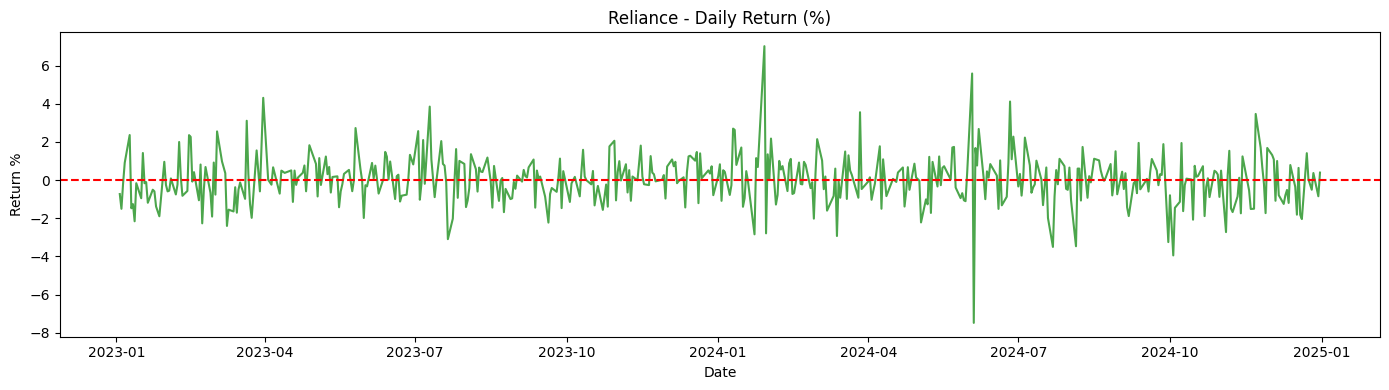

Average Daily Return: 0.014 %
Max Gain in a Day:    7.02 %
Max Loss in a Day:    -7.49 %


In [21]:
#Daily Returns
df['Daily_Return'] = df['Close'].pct_change() * 100

plt.figure(figsize=(14,4))
plt.plot(df['Date'].values, df['Daily_Return'].values, color='green', alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title('Reliance - Daily Return (%)')
plt.xlabel('Date')
plt.ylabel('Return %')
plt.tight_layout()
plt.show()

print("Average Daily Return:", round(float(df['Daily_Return'].mean()), 3), "%")
print("Max Gain in a Day:   ", round(float(df['Daily_Return'].max()), 2), "%")
print("Max Loss in a Day:   ", round(float(df['Daily_Return'].min()), 2), "%")

In [25]:
from prophet import Prophet

# Data prepare 
prophet_df = df[['Date', 'Close']].copy()
prophet_df.columns = ['ds', 'y']
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])
prophet_df['y'] = prophet_df['y'].astype(float)

print(prophet_df.head())
print(prophet_df.dtypes)

Importing plotly failed. Interactive plots will not work.


          ds            y
0 2023-01-02  1175.889648
1 2023-01-03  1167.284668
2 2023-01-04  1149.709595
3 2023-01-05  1147.655151
4 2023-01-06  1158.086304
ds    datetime64[s]
y           float64
dtype: object


In [26]:
# Model 
model = Prophet(daily_seasonality=True)
model.fit(prophet_df)

# Next 30 days future plane
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

print("✅ Model trained successfully!")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

18:12:01 - cmdstanpy - INFO - Chain [1] start processing
18:12:02 - cmdstanpy - INFO - Chain [1] done processing


✅ Model trained successfully!
            ds         yhat   yhat_lower   yhat_upper
511 2025-01-21  1168.709762  1127.187558  1207.465498
512 2025-01-22  1167.923795  1130.585076  1207.121535
513 2025-01-23  1165.813960  1125.602633  1206.786621
514 2025-01-24  1165.538607  1124.749761  1206.799860
515 2025-01-25  1167.106938  1126.338412  1208.432969
516 2025-01-26  1165.055665  1126.086517  1206.037861
517 2025-01-27  1161.679684  1119.034531  1203.004918
518 2025-01-28  1154.350863  1112.544425  1196.571746
519 2025-01-29  1153.564897  1112.430043  1193.001926
520 2025-01-30  1151.455061  1109.769390  1192.166763


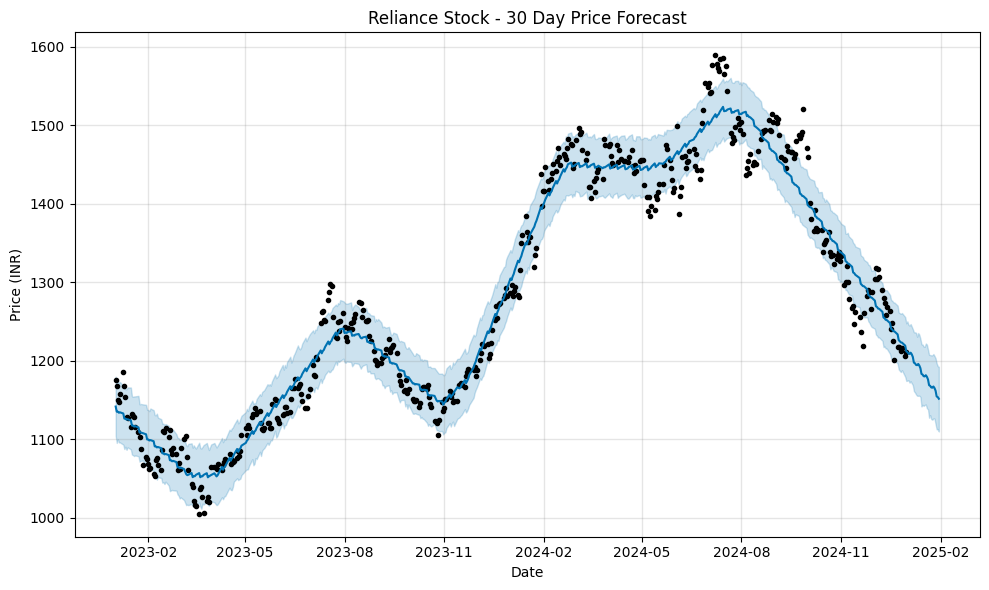

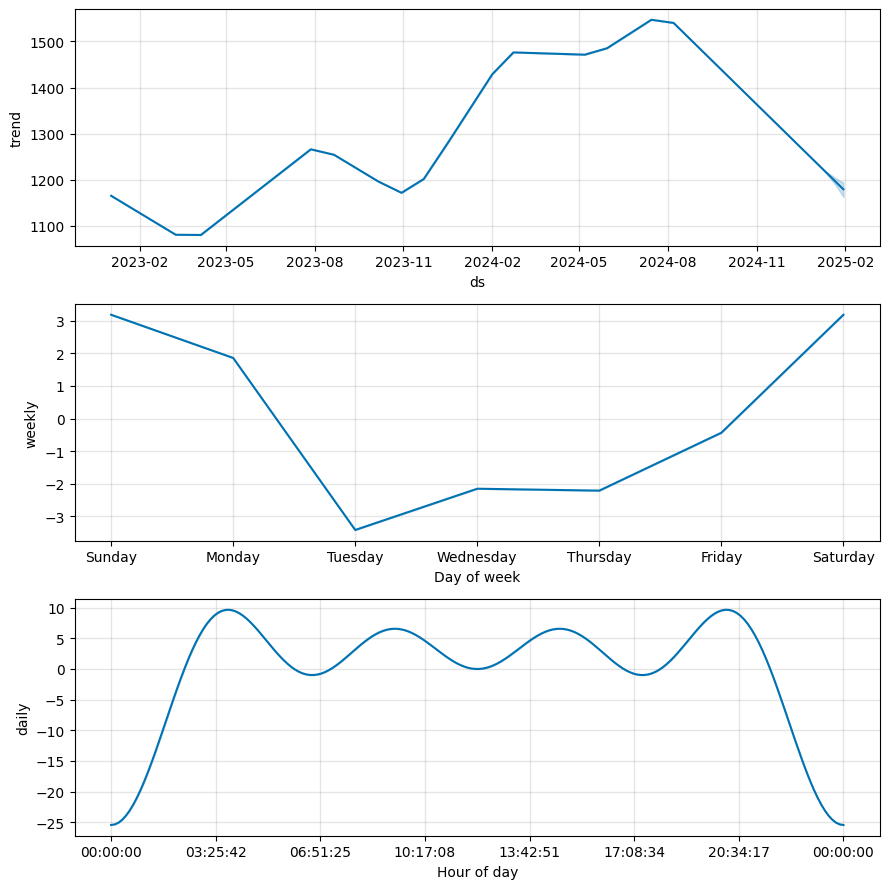

In [27]:
# Forecast chart
fig1 = model.plot(forecast)
plt.title('Reliance Stock - 30 Day Price Forecast')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.tight_layout()
plt.show()

# Trend + Seasonality breakdown
fig2 = model.plot_components(forecast)
plt.tight_layout()
plt.show()

In [28]:
# Export Data for power bi
df.to_csv('reliance_final.csv', index=False)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv('reliance_forecast.csv', index=False)

print("✅ Done! 2 files save ho gayi:")
print("   📁 reliance_final.csv")
print("   📁 reliance_forecast.csv")

✅ Done! 2 files save ho gayi:
   📁 reliance_final.csv
   📁 reliance_forecast.csv
